# SVM：一条有「间隔」的直线

**课程 0008 配套练习** · 内核：`deeplearning`

前置：课程 0004（逻辑回归）+ 0007（决策树）。逻辑回归的边界被「所有样本」拉扯；SVM 只关心离边界最近的少数点，并用力推开它们——这就是**最大间隔**。它自带稀疏性，还引出核技巧。

> 读完后请回答：为什么「只由少数支持向量决定」反而比「所有样本一起决定」更稳？

## 问题设定：两类高斯团（有重叠）

带重叠的两团数据最适合看「间隔」的价值：所有可行的分界线里，离两团都更远的那条更抗噪。

train: (140, 2) test: (60, 2)


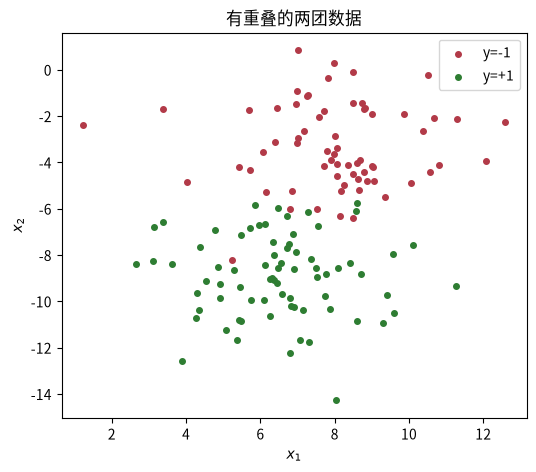

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 中文字体
import matplotlib as mpl
from matplotlib import font_manager
for name in ["Noto Sans CJK SC", "Noto Serif CJK SC", "WenQuanYi Zen Hei", "SimHei"]:
    if any(f.name == name for f in font_manager.fontManager.ttflist):
        mpl.rcParams["font.sans-serif"] = [name]
        break
mpl.rcParams["axes.unicode_minus"] = False

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.8, random_state=6)
y = np.where(y == 0, -1, 1)                 # SVM 约定标签 ±1
# p.where(条件, 条件为真时的值, 条件为假时的值)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
print("train:", Xtr.shape, "test:", Xte.shape)

plt.figure(figsize=(6, 5))
plt.scatter(Xtr[ytr == -1, 0], Xtr[ytr == -1, 1], c="#b23a48", s=16, label="y=-1")
plt.scatter(Xtr[ytr == 1, 0], Xtr[ytr == 1, 1], c="#2e7d32", s=16, label="y=+1")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.title("有重叠的两团数据")
plt.show()

## 合页损失：软间隔 SVM 的「策略」

SVM 最大化间隔等价于最小化如下目标（合页损失 + L2 正则）：

$$\min_{w, b} \; \frac{1}{2}\|w\|^2 + C \sum_i \max(0, \, 1 - y_i(w^\top x_i + b))$$

- 对「正确且离边界够远」的样本，$y_i(w^\top x_i+b) \ge 1$，损失为 0——它们不影响解。
- 落在间隔带内或分错的样本，损失线性增长——它们就是支持向量（或违规者）。
- $C$ 控制后一项的权重：大 $C$ 严格、间隔窄；小 $C$ 宽容、间隔宽。

**C 很大：对错误惩罚很重。尽量不允许样本违规，愿意牺牲间隔宽度，把间隔压窄，容易过拟合。**

**C 很小：对误分类、间隔内样本更宽容；优先追求更宽的间隔，可以容忍一部分样本出错。**

我们用手写 SGD 去最小化它（这就是「算法」）。

In [11]:
def train_svm_sgd(X, y, lr=0.01, C=1.0, steps=5000, seed=42):
    """合页损失 + L2 的 SGD（软间隔 SVM 的次梯度形式）。返回 (w, b)。
    每一步，只用1 个随机抽取的样本去估计梯度，立刻更新参数。
    """
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    rng = np.random.default_rng(seed)
    for t in range(steps):
        lr_t = lr / (1 + 0.05 * t / steps)          # 学习率衰减
        for i in rng.permutation(n):        # Randomly permute a sequence，if n is integer, it is treated as np.arange(n)
            # 只有支持向量才产生梯度、更新参数。
            # SVM中认为:样本只要正确、并且离间隔边界≥1（安全区），就完全不用管它，不参与优化。
            if y[i] * (w @ X[i] + b) < 1:           # 支持向量 / 违规者：更新
                w = (1 - lr_t) * w + lr_t * C * y[i] * X[i]
                b += lr_t * C * y[i]
            else:                                    # 正确且足够远：只做 L2 收缩
                w = (1 - lr_t) * w
    return w, b

w, b = train_svm_sgd(Xtr, ytr, C=1.0)
pred = np.sign(Xte @ w + b)
print("手写 SVM 测试准确率：", round(float(np.mean(pred == yte)), 3))
print("几何间隔 1/‖w‖：", round(1 / np.linalg.norm(w), 3))

手写 SVM 测试准确率： 0.983
几何间隔 1/‖w‖： 1.742


## 画出间隔带与支持向量

「间隔带内或违规」的样本：$y_i(w^\top x_i + b) \le 1$。注意这里只是**可视化用的近似**——严格意义上的支持向量由对偶问题的非零乘子决定（sklearn 的 `clf.support_`），验证解不变时要用 `clf.support_`。

支持向量数量： 40 / 140 （29%）


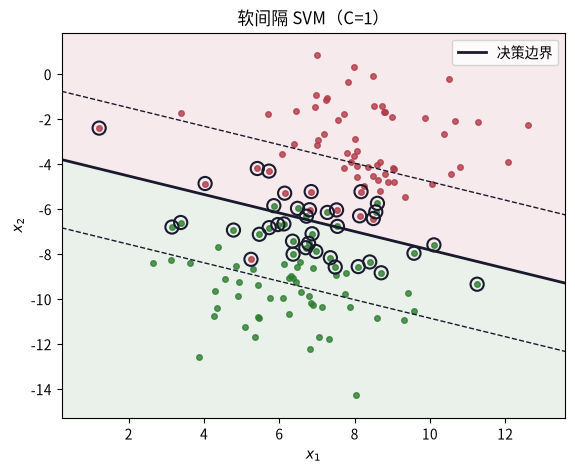

In [ ]:
def plot_svm(X, y, w, b, ax, title):
    x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)
    x2 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
    xx, yy = np.meshgrid(x1, x2)
    Z = np.sign(xx * w[0] + yy * w[1] + b)
    ax.contourf(xx, yy, Z, levels=1, colors=["#b23a48", "#2e7d32"], alpha=0.10)
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c="#b23a48", s=16, alpha=0.8)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#2e7d32", s=16, alpha=0.8)
    margin = 1 / np.linalg.norm(w)
    xxline = np.array([x1.min(), x1.max()])
    yyline = -(w[0] * xxline + b) / w[1]        # 其实和逻辑回归差不多，都是拿到参数后反解
    ax.plot(xxline, yyline, color="#1a1a2e", lw=2, label="决策边界")
    ax.plot(xxline, yyline + margin / np.linalg.norm(w), "--", color="#1a1a2e", lw=1)
    ax.plot(xxline, yyline - margin / np.linalg.norm(w), "--", color="#1a1a2e", lw=1)
    ax.set_title(title); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.legend()

# 支持向量：间隔内或违规的样本
scores = ytr * (Xtr @ w + b)
sv_mask = scores <= 1
print("支持向量数量：", sv_mask.sum(), "/", len(ytr), f"（{sv_mask.mean():.0%}）")

fig, ax = plt.subplots(figsize=(6.5, 5))
plot_svm(Xtr, ytr, w, b, ax, "软间隔 SVM（C=1）")
ax.scatter(Xtr[sv_mask, 0], Xtr[sv_mask, 1], facecolors="none", edgecolors="#1a1a2e", s=90, lw=1.5, label="支持向量")
'''
facecolors="none"：内部填充色透明，空心圆点
edgecolors="#1a1a2e"：点的边框颜色为深近黑色
s=90：散点大小
lw=1.5：边框线宽 1.5
'''
plt.show()

## sklearn 版：LinearSVC + 与逻辑回归对比

sklearn 帮你解对偶问题（更准）。同一数据上对比：SVM 与逻辑回归的边界谁更「居中」、谁更在意重叠点。

sklearn 线性 SVM 测试准确率： 0.983
支持向量数量： [9 9]


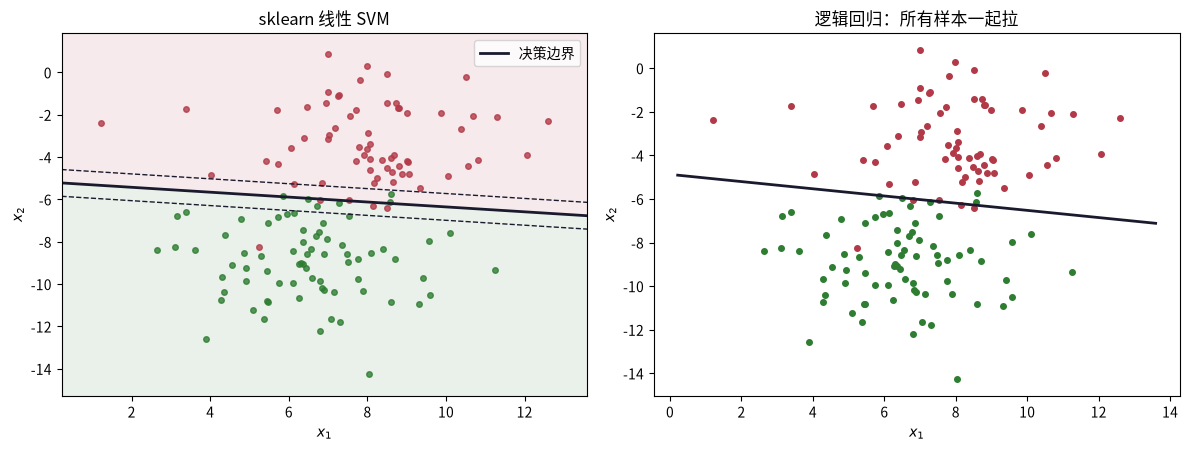

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

clf = SVC(kernel="linear", C=1.0).fit(Xtr, ytr)
print("sklearn 线性 SVM 测试准确率：", round(float(clf.score(Xte, yte)), 3))
print("支持向量数量：", clf.n_support_)

# 逻辑回归：把 y 映射回 0/1
lr = LogisticRegression().fit(Xtr, (ytr + 1) // 2)
w_lr = np.r_[lr.coef_.ravel(), lr.intercept_]   # np.r_ 是按行拼接数组，返回一个一维数组，相当于hstack((lr.coef_.ravel(), lr.intercept_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
w_svm, b_svm = clf.coef_.ravel(), clf.intercept_[0]
plot_svm(Xtr, ytr, w_svm, b_svm, axes[0], "sklearn 线性 SVM")
# 逻辑回归边界（单线）
axes[1].scatter(Xtr[ytr == -1, 0], Xtr[ytr == -1, 1], c="#b23a48", s=16)
axes[1].scatter(Xtr[ytr == 1, 0], Xtr[ytr == 1, 1], c="#2e7d32", s=16)
xx = np.linspace(Xtr[:, 0].min() - 1, Xtr[:, 0].max() + 1, 300)
yy = -(w_lr[0] * xx + w_lr[2]) / w_lr[1]
axes[1].plot(xx, yy, color="#1a1a2e", lw=2)
axes[1].set_title("逻辑回归：所有样本一起拉"); axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$")
plt.tight_layout(); plt.show()

## 核技巧：把直线变曲线

环形数据（make_circles）线性分不开。核技巧的关键：SVM 的对偶问题里，数据只以内积 ⟨xᵢ, xⱼ⟩ 出现。把内积换成核函数 $K(x_i, x_j) = \exp(-\gamma \|x_i-x_j\|^2)$（RBF/高斯核），就相当于在隐式高维空间做线性 SVM——而 RBF 核隐式的映射是无穷维的。

线性 SVM 在环形数据上： 0.45
RBF   SVM 在环形数据上： 1.0


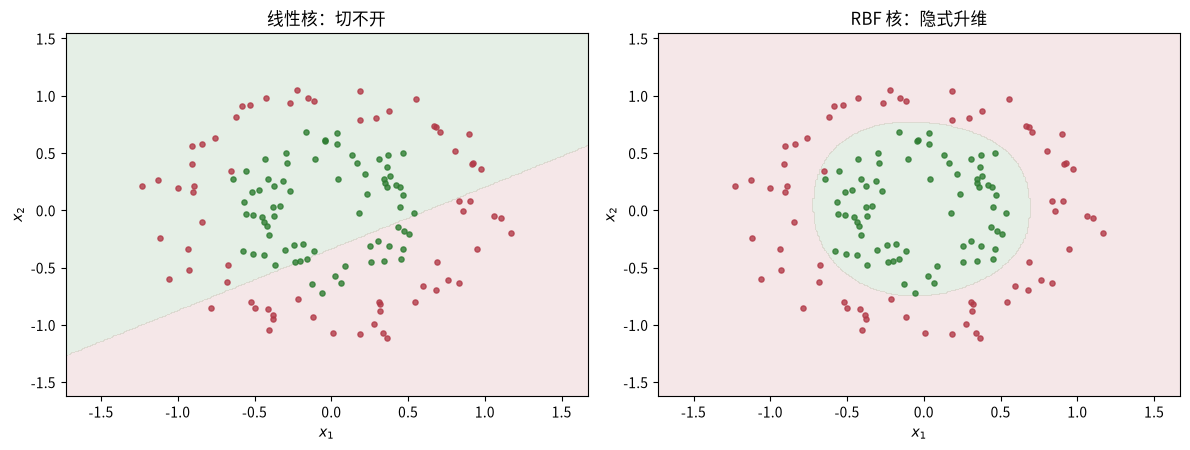

In [ ]:
from sklearn.datasets import make_circles

Xc, yc = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=0)
yc = np.where(yc == 0, -1, 1)
Xctr, Xcte, yctr, ycte = train_test_split(Xc, yc, test_size=0.3, random_state=0)

lin = SVC(kernel="linear", C=1.0).fit(Xctr, yctr)
rbf = SVC(kernel="rbf", C=1.0, gamma=2.0).fit(Xctr, yctr)       # gamma 越大，RBF 核越尖锐，越容易过拟合
print("线性 SVM 在环形数据上：", round(float(lin.score(Xcte, ycte)), 3))
print("RBF   SVM 在环形数据上：", round(float(rbf.score(Xcte, ycte)), 3))

def plot_circle_boundary(clf, X, y, ax, title):
    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)
    x2 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
    xx, yy = np.meshgrid(x1, x2)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=1, colors=["#b23a48", "#2e7d32"], alpha=0.12)
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c="#b23a48", s=14, alpha=0.8)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#2e7d32", s=14, alpha=0.8)
    ax.set_title(title); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
plot_circle_boundary(lin, Xctr, yctr, axes[0], "线性核：切不开")
plot_circle_boundary(rbf, Xctr, yctr, axes[1], "RBF 核：隐式升维")
plt.tight_layout(); plt.show()

## 手写 RBF 核的预测

sklearn 训练完只保留支持向量 + 对偶系数。预测就是对支持向量做核函数加权求和：

$$f(x) = \sum_{i \in SV} \alpha_i y_i K(x, x_i) + b$$

这正说明「模型只由支持向量决定」不是口号——预测时其它样本根本不在。

In [ ]:
def rbf_kernel(A, B, gamma):
    """高斯核：exp(-gamma * ||a - b||^2)。"""
    d2 = ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=-1)
    return np.exp(-gamma * d2)

def predict_rbf(X, support_vectors, dual_coef, intercept, gamma):
    K = rbf_kernel(X, support_vectors, gamma)   # (n_test, n_sv)，先做一个核函数变换到高维然后再进行决策函数求和
    return np.sign(K @ dual_coef.ravel() + intercept)   # 做 SVM 决策函数求和
# np.sign()：返回数组中每个元素的符号，正数为 1，负数为 -1，0 为 0，其实就是实现了上面的f(x)函数

# sklearn 的 gamma='scale' 对应 1/(n_features * X.var())
gamma_scale = 1.0 / (Xctr.shape[1] * Xctr.var())
rbf2 = SVC(kernel="rbf", C=1.0, gamma=gamma_scale).fit(Xctr, yctr)
pred_hand = predict_rbf(Xcte, rbf2.support_vectors_, rbf2.dual_coef_, rbf2.intercept_, gamma_scale)
print("手写 RBF 预测准确率：", round(float(np.mean(pred_hand == ycte)), 3))
print("sklearn RBF 准确率：", round(float(rbf2.score(Xcte, ycte)), 3))
print("支持向量数：", len(rbf2.support_vectors_), "/", len(Xctr))

手写 RBF 预测准确率： 1.0
sklearn RBF 准确率： 1.0
支持向量数： 43 / 140


## 练习（S 理解 / M 动手 / H 挑战）

**S1.** 去掉所有非支持向量的训练样本，SVM 的解会不会变？用 sklearn 的 `clf.support_` 挑出支持向量重新训练（`Xtr[sv_idx], ytr[sv_idx]`），对比 w 与测试准确率。

**S2.** 间隔带为什么是「边界两侧各 1/‖w‖」？画图：把 margin 的虚线延长，看它和决策边界的关系。

**M1.** 把 `train_svm_sgd` 的 `C` 从 0.001 扫到 100，记录每个 C 下的（支持向量数、间隔宽度、train/test 准确率）。C 变大时间隔怎么变？测试准确率怎么变？

**M2.** 在环形数据上把 `gamma` 从 0.05 扫到 100（固定 C=1），画出 train/test 准确率曲线，找最佳 γ，说明两端各是偏差还是方差。

**H1.** 手写 RBF 核的预测已经完成——现在验证「去掉非支持向量不影响预测」：把 sklearn 的 `dual_coef_` 对应到支持向量重新算一遍 `decision_function`，和 `rbf2.decision_function(Xcte)` 对比是否一致。

**H2.** 面试题：为什么 SVM 用对偶问题而不是直接解原始问题？结合「核技巧」和「支持向量的稀疏性」各说一点。

In [ ]:
# pass  # 练习区（S1/S2）
# 不变
# 用点到直线距离公式可以解释

In [ ]:
# pass  # 练习区（M1/M2）

# C 变大，间隔变窄；测试集率先升后降。

In [ ]:
# pass  # 练习区（H1/H2）

# 预测只依赖少量支持向量，计算高效。